# Predictive science for crop-protection field trials

This notebook demonstrates the full reasoning chain: **experimental structure → dose response → validation → uncertainty → next experiment**. The data are synthetic and generated from an explicit, inspectable DGP.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
summary = json.loads((ROOT / "results" / "summary.json").read_text())
summary["n_rows"], summary["n_sites"], summary["years"]

(1152, 8, [2023, 2024, 2025])

## 1. Validation must match the scientific extrapolation

Random K-fold CV allows a model to see every site during training. Leave-one-site-out validation asks the harder and often more relevant question: **can the model transport to a new experimental environment?**

In [2]:
cv = pd.read_csv(ROOT / "results" / "validation_comparison.csv")
cv

,strategy,n_folds,rmse,mae,r2
0,random_5fold,5,0.054745,0.041986,0.970563
1,leave_one_site_out,8,0.060746,0.046507,0.963755


In [3]:
random_rmse = float(cv.loc[cv.strategy == "random_5fold", "rmse"].iloc[0])
site_rmse = float(cv.loc[cv.strategy == "leave_one_site_out", "rmse"].iloc[0])
relative_gap = 100 * (site_rmse / random_rmse - 1)
print(f"Unseen-site RMSE is {relative_gap:.1f}% higher than random-CV RMSE.")

Unseen-site RMSE is 11.0% higher than random-CV RMSE.


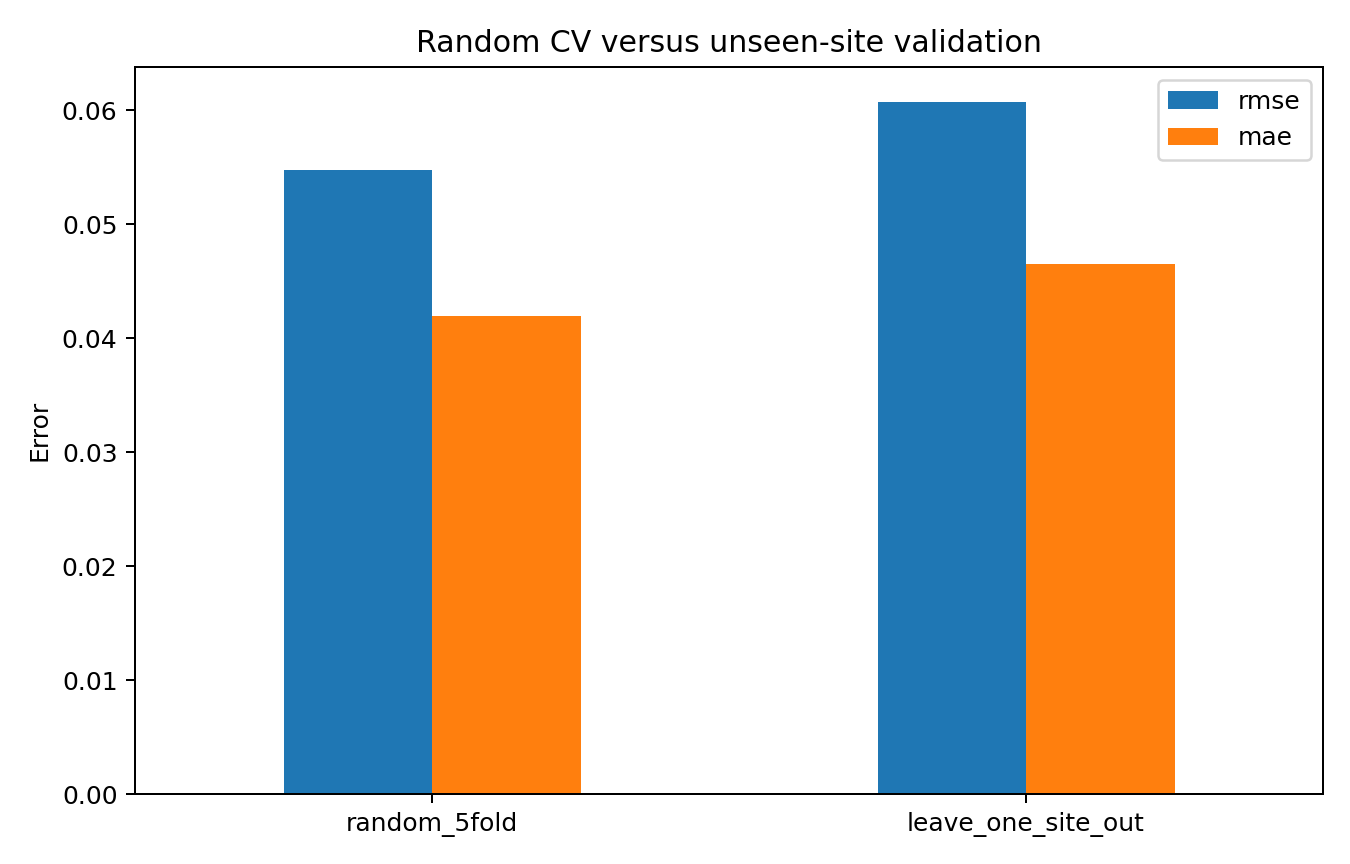

In [4]:
display(Image(filename=str(ROOT / "results" / "figures" / "validation_gap.png")))

## 2. Dose response and uncertainty

A four-parameter logistic curve is fitted to Formulation A. ED50 and ED90 uncertainty comes from resampling **trial clusters**, preserving the dependence structure within each field-trial block.

In [5]:
dose = summary["dose_response"]
pd.DataFrame({
    "estimate": [dose["ed50"], dose["ed90"], dose["hill"]],
    "parameter": ["ED50", "ED90", "Hill coefficient"],
}).set_index("parameter")

,estimate
parameter,
ED50,10.936310
ED90,41.844913
Hill coefficient,1.637420


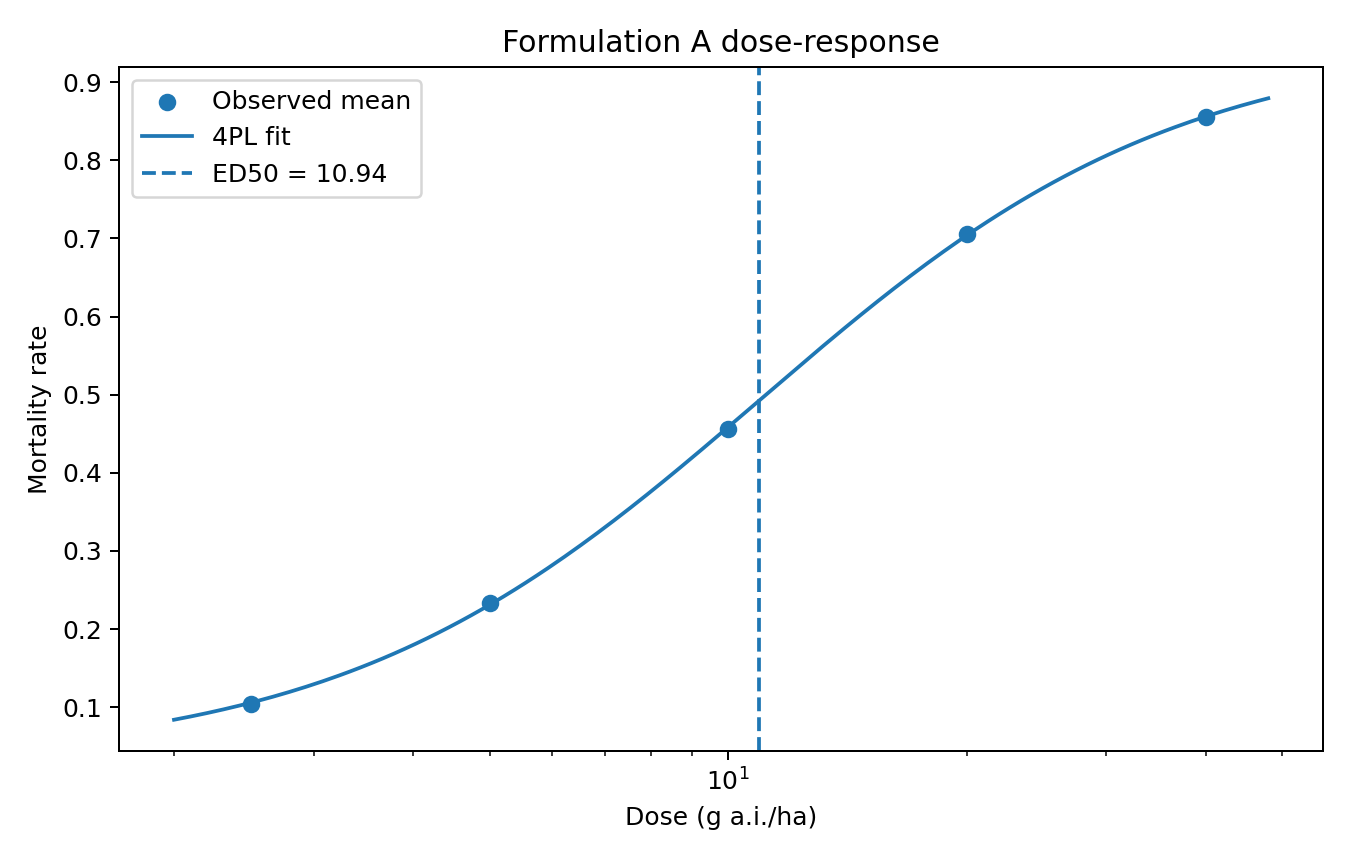

In [6]:
display(Image(filename=str(ROOT / "results" / "figures" / "dose_response.png")))

## 3. Hierarchical variation

The mixed-effects model includes a site random intercept. This makes between-site heterogeneity explicit instead of pretending all observations are exchangeable.

In [7]:
print(f"Estimated site random-intercept variance: {summary['site_random_intercept_variance']:.4f}")

Estimated site random-intercept variance: 0.0564


## 4. Use the model to choose the next experiment

The final step is not another metric. Candidate dose × temperature × spray-coverage conditions are ranked with a transparent D-optimality criterion so that the next experiment is chosen to add information.

In [8]:
pd.read_csv(ROOT / "results" / "next_experiment_design.csv")

,rank,dose_g_ai_ha,temperature_c,spray_coverage_pct
0,1,15.0,20.0,85.0
1,2,15.0,30.0,45.0
2,3,10.0,30.0,85.0
3,4,5.0,20.0,45.0
4,5,40.0,20.0,45.0
5,6,5.0,20.0,85.0


## Takeaway

The portfolio signal is the workflow, not the random-forest score: **scientific question, experimental unit, hierarchy, non-linearity, domain-shift validation, uncertainty and sequential design**.